# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## Task 0 - Exploratory Data Analysis

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Loading Data

In [2]:
df_donors = pd.read_csv('Donors_dataset.csv')

In [3]:
# Data Set Visualization
df_donors.head()

,TARGET_B,TARGET_D,CONTROL_NUMBER,MONTHS_SINCE_ORIGIN,DONOR_AGE,IN_HOUSE,URBANICITY,SES,CLUSTER_CODE,HOME_OWNER,...,LIFETIME_GIFT_RANGE,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LAST_GIFT_AMT,CARD_PROM_12,NUMBER_PROM_12,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT,FILE_AVG_GIFT,FILE_CARD_GIFT
0,0,NaN,5,101,87.0,0,?,?,.,H,...,15.0,20.0,5.0,15.0,5,12,26,92,8.49,7
1,1,10.0,12,137,79.0,0,R,2,45,H,...,20.0,25.0,5.0,17.0,7,21,7,122,14.72,12
2,0,NaN,37,113,75.0,0,S,1,11,H,...,23.0,28.0,5.0,19.0,11,32,6,105,16.75,16
3,0,NaN,38,92,NaN,0,U,2,4,H,...,14.0,17.0,3.0,15.0,11,33,6,92,11.76,12
4,0,NaN,41,101,74.0,0,R,2,49,U,...,20.0,25.0,5.0,25.0,6,19,18,92,8.83,3


In [4]:
# Data Structure Verification
print(f'df_donors')
print({df_donors.info()})

df_donors
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19372 entries, 0 to 19371
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TARGET_B                     19372 non-null  int64  
 1   TARGET_D                     4843 non-null   float64
 2   CONTROL_NUMBER               19372 non-null  int64  
 3   MONTHS_SINCE_ORIGIN          19372 non-null  int64  
 4   DONOR_AGE                    14577 non-null  float64
 5   IN_HOUSE                     19372 non-null  int64  
 6   URBANICITY                   19372 non-null  object 
 7   SES                          19372 non-null  object 
 8   CLUSTER_CODE                 19372 non-null  object 
 9   HOME_OWNER                   19372 non-null  object 
 10  DONOR_GENDER                 19372 non-null  object 
 11  INCOME_GROUP                 14980 non-null  float64
 12  PUBLISHED_PHONE              19372 non-null  int64  
 13  OVERLA

## 0.2. Understanding Data

In this task you should **understand better the features**, their distribution of values, potential errors, etc and plan/describe what data preprocessing steps should be performed next. Very important also is the distribution of values in the target (class distribution). 

Here you can find a notebook with some examples of what you can do in **Exploratory Data Analysis**: https://www.kaggle.com/artgor/exploration-of-data-step-by-step/notebook. You can also use Orange widgets for this.

In [10]:
# Missing Data Identification (Null Values Check)
missing_data = df_donors.isnull().sum()
print(missing_data[missing_data > 0])

TARGET_D                       14529
DONOR_AGE                       4795
INCOME_GROUP                    4392
WEALTH_RATING                   8810
MONTHS_SINCE_LAST_PROM_RESP      246
dtype: int64


In [8]:
# Selecting only numerical variables for correlation analysis
numerical_columns = df_donors.select_dtypes(include=['float64', 'int64']).columns

# Initialize a dictionary to hold the correlation values
correlation_dict = {}

# Calculate Pearson correlation for TARGET_D with each numerical variable
for column in numerical_columns:
    if column != 'TARGET_D' and column != 'TARGET_B':  # Skip the target variable and TARGET_B
        correlation = df_donors['TARGET_D'].corr(df_donors[column])
        correlation_dict[column] = correlation

# Convert the dictionary to a DataFrame for better visualization
correlation_table = pd.DataFrame(correlation_dict.items(), columns=['Variable', 'Pearson Coefficient'])

# Sort the DataFrame by 'Pearson Coefficient' in descending order
correlation_table_sorted = correlation_table.sort_values(by='Pearson Coefficient', ascending=False)

# Display the sorted correlation table
print(correlation_table_sorted.reset_index(drop=True))

                       Variable  Pearson Coefficient
0           RECENT_AVG_GIFT_AMT             0.707250
1                 LAST_GIFT_AMT             0.645388
2                 FILE_AVG_GIFT             0.516724
3         LIFETIME_AVG_GIFT_AMT             0.516724
4      RECENT_AVG_CARD_GIFT_AMT             0.477654
5         LIFETIME_MAX_GIFT_AMT             0.443145
6           LIFETIME_GIFT_RANGE             0.338629
7         LIFETIME_MIN_GIFT_AMT             0.295783
8          LIFETIME_GIFT_AMOUNT             0.247667
9             PER_CAPITA_INCOME             0.135409
10  MONTHS_SINCE_LAST_PROM_RESP             0.133834
11            MEDIAN_HOME_VALUE             0.126180
12                 INCOME_GROUP             0.126074
13      MEDIAN_HOUSEHOLD_INCOME             0.118255
14                WEALTH_RATING             0.114298
15       MONTHS_SINCE_LAST_GIFT             0.090215
16               NUMBER_PROM_12             0.064494
17                     IN_HOUSE             0.

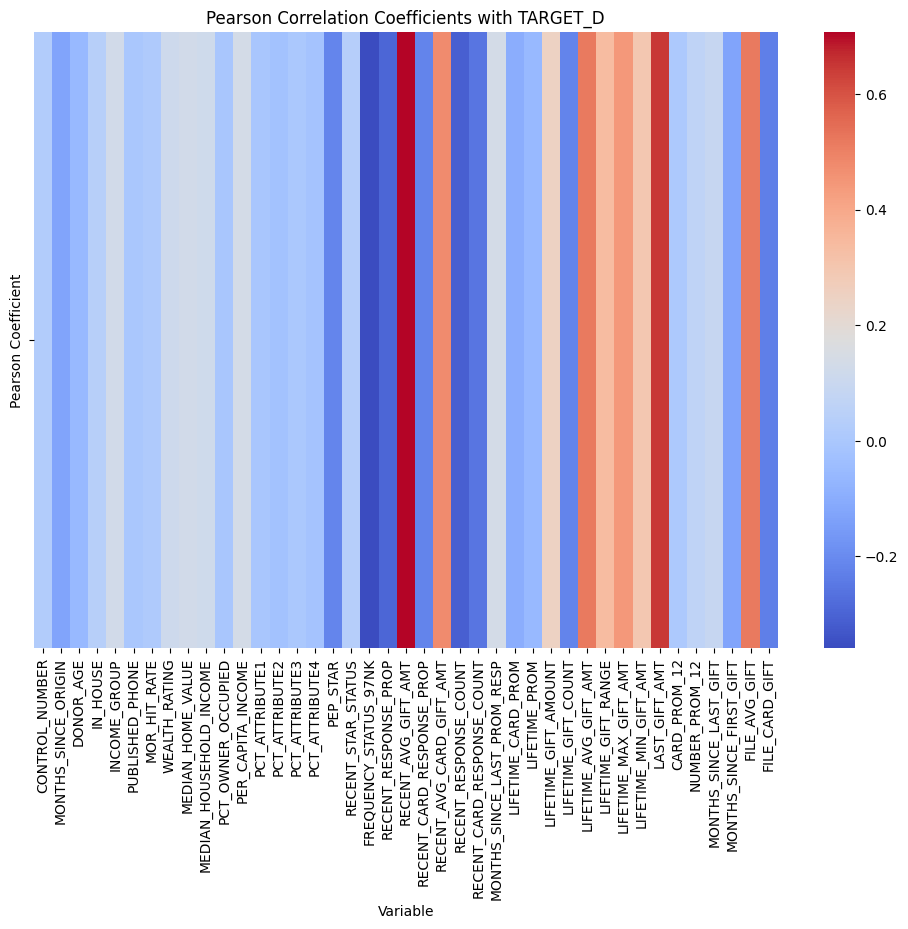

In [ ]:
# Heatmap Visualization of Correlation Coefficients
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_table.set_index('Variable').T, cmap='coolwarm', cbar=True, fmt=".2f")
plt.title('Pearson Correlation Coefficients with TARGET_D')
plt.show()

In [ ]:
# Strongly Positive Correlations (potential features for modeling)
#
#     RECENT_AVG_GIFT_AMT:         0.707250
#     LAST_GIFT_AMT:               0.645388
#     FILE_AVG_GIFT:               0.516724
#     LIFETIME_AVG_GIFT_AMT:       0.516724
#     RECENT_AVG_CARD_GIFT_AMT:    0.477654
#     LIFETIME_MAX_GIFT_AMT:       0.443145
#     LIFETIME_GIFT_RANGE:         0.338629
#     LIFETIME_MIN_GIFT_AMT:       0.295783
#     LIFETIME_GIFT_AMOUNT:        0.247667
#     PER_CAPITA_INCOME:           0.135409
#     MONTHS_SINCE_LAST_PROM_RESP: 0.133834
#     MEDIAN_HOME_VALUE:           0.126180
#     INCOME_GROUP:                 0.126074
#     MEDIAN_HOUSEHOLD_INCOME:      0.118255
#     WEALTH_RATING:                0.114298
#
# Strongly Negative Correlations (potential features for modeling)
#
#     FREQUENCY_STATUS_97NK:         -0.358655
#     RECENT_RESPONSE_COUNT:         -0.312299
#     RECENT_RESPONSE_PROP:          -0.292625
#     RECENT_CARD_RESPONSE_COUNT:    -0.256911
#     FILE_CARD_GIFT:                -0.229592
#     RECENT_CARD_RESPONSE_PROP:     -0.221056
#     LIFETIME_GIFT_COUNT:           -0.220247
#     PEP_STAR:                      -0.215399
#     MONTHS_SINCE_FIRST_GIFT:      -0.127522
#     MONTHS_SINCE_ORIGIN:           -0.126858
#     DONOR_AGE:                    -0.056139
#     LIFETIME_PROM:                -0.057903
#     LIFETIME_CARD_PROM:           -0.097675

In [11]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Identifying categorical variables
categorical_columns = df_donors.select_dtypes(include=['object']).columns

# Results for ANOVA
anova_results = {}

for column in categorical_columns:
    if column != 'TARGET_D':  # Ignoring the target variable
        # Fitting the ANOVA model
        model = ols(f'TARGET_D ~ C({column})', data=df_donors).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Storing results
        anova_results[column] = anova_table['PR(>F)'].iloc[0]  # P-value

# Converting results to DataFrame for better visualization
anova_results_df = pd.DataFrame(anova_results.items(), columns=['Variable', 'P-Value'])

# Displaying the results
print(anova_results_df)

              Variable       P-Value
0           URBANICITY  1.612702e-09
1                  SES  3.165017e-13
2         CLUSTER_CODE  3.142542e-08
3           HOME_OWNER  5.895921e-01
4         DONOR_GENDER  4.872228e-12
5       OVERLAY_SOURCE  2.945736e-01
6  RECENCY_STATUS_96NK  1.487957e-64


In [ ]:
# Interpretation of Results
#
# The printed DataFrame shows the categorical variables with their respective p-values:
#
#     URBANICITY: 1.612702e-09 — Significant.
#     SES: 3.165017e-13 — Highly significant.
#     CLUSTER_CODE: 3.142542e-08 — Significant.
#     HOME_OWNER: 5.895921e-01 — Not significant.
#     DONOR_GENDER: 4.872228e-12 — Highly significant.
#     OVERLAY_SOURCE: 2.945736e-01 — Not significant.
#     RECENCY_STATUS_96NK: 1.487957e-64 — Highly significant.
#
# Considerations
#
#     P-values < 0.05: Variables with very low p-values (such as URBANICITY, SES,
#     CLUSTER_CODE, DONOR_GENDER, and RECENCY_STATUS_96NK) are statistically significant
#     and may be included in the prediction model.
#     P-values > 0.05: Variables like HOME_OWNER and OVERLAY_SOURCE do not have a
#     significant association with TARGET_D and could be excluded in the context of the model.

...

## 0.3. Preprocessing Data

Here you might perform data preprocessing that will be used for both supervised and unsupervised learning tasks.

...

## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

**You should:**

* Choose **5 classifiers** from **at least 3 of the following categories**: Tree models, Probabilistic models, Distance-based models and Linear models. You can also try one Ensemble Classifier (https://scikit-learn.org/1.5/modules/ensemble.html). 
* Use **cross-validation** to evaluate the results.
* Describe the parameters used for each classifier and how their choice impacted or not the results.
* Choose the **best classifier** and fundament you choice.
* Present and discuss the results for different evaluation measures, present confusion matrices. Remember that not only overall results are important. Check what happens when learning to predict each class. Remember also that some metrics might be more adequate than others according to the problem at hand.

* **Discuss critically your choices and the results!**

## 1.1. Specific Data Preprocessing for Classification

## 1.2. Learning and Evaluating Classifiers

...

O objetivo deste trabalho foi desenvolver um modelo de classificação utilizando uma Árvore de Decisão para prever a probabilidade de indivíduos se tornarem doadores. O modelo foi treinado com 18 características selecionadas heurística e numericamente, incluindo tanto atributos numéricos quanto categóricos. 


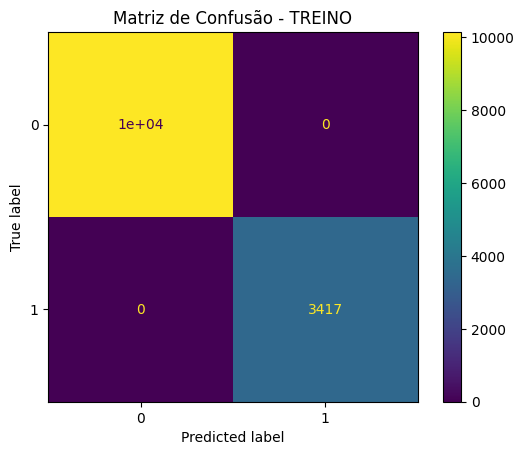

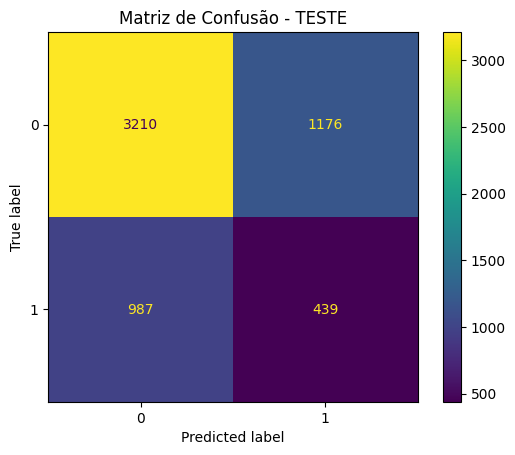

Matriz de Confusão - TREINO (lista): [[10143, 0], [0, 3417]]
Matriz de Confusão - TESTE (lista): [[3210, 1176], [987, 439]]

CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10143
           1       1.00      1.00      1.00      3417

    accuracy                           1.00     13560
   macro avg       1.00      1.00      1.00     13560
weighted avg       1.00      1.00      1.00     13560

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.76      0.73      0.75      4386
           1       0.27      0.31      0.29      1426

    accuracy                           0.63      5812
   macro avg       0.52      0.52      0.52      5812
weighted avg       0.64      0.63      0.64      5812



In [17]:
# Decision Tree Classifier for TARGET_B with 18 features selected heuristically

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT", 
    "LAST_GIFT_AMT", 
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", 
    "LIFETIME_MAX_GIFT_AMT", 
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", 
    "MONTHS_SINCE_FIRST_GIFT", 
    "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", 
    "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", 
    "RECENT_RESPONSE_COUNT", 
    "WEALTH_RATING"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Display the confusion matrices as lists
print("Matriz de Confusão - TREINO (lista):", train_matrix_list)
print("Matriz de Confusão - TESTE (lista):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))


O modelo obteve uma accuracy de 100% no conjunto de dados de treino, o que é alarmante e sugere que aprendeu os dados de treino em detrimento da generalização para novos dados. A accuracy de 63% no conjunto de dados teste, além das métricas relativamente baixas para a classe 1, confirma que o modelo não se generaliza bem. Isso aponta para um alto número de falsos negativos e uma incapacidade de prever novos doadores. Embora o modelo de árvore de decisão tenha mostrado um desempenho excelente nos dados de treino, a evidência clara de overfitting indica a necessidade de ajustes.

A etapa seguinte consistiu em treinar um modelo de Árvore de Decisão para prever a classificação da variável TARGET_B utilizando 10 características selecionadas com base na correlação, utilizando o coeficiente de Pearson para as variáveis numéricas e o teste de ANOVA para as variáveis categóricas. Esta abordagem visa garantir que as características escolhidas tenham uma relação significativa com a variável alvo.

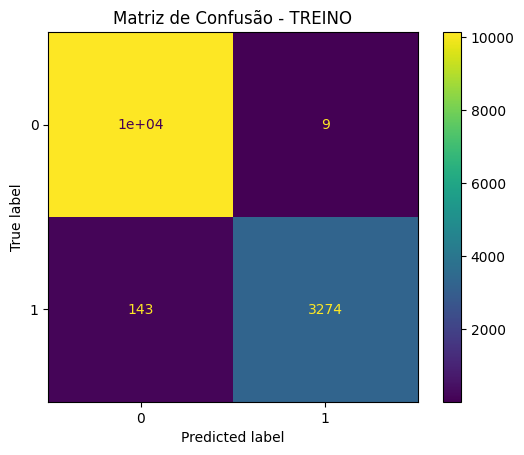

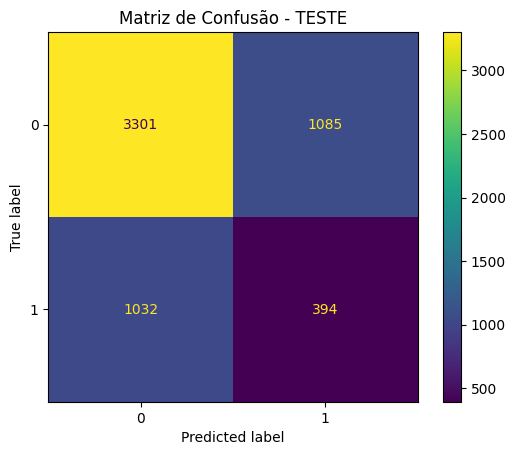

Matriz de Confusão - TREINO (lista): [[10134, 9], [143, 3274]]
Matriz de Confusão - TESTE (lista): [[3301, 1085], [1032, 394]]

CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     10143
           1       1.00      0.96      0.98      3417

    accuracy                           0.99     13560
   macro avg       0.99      0.98      0.98     13560
weighted avg       0.99      0.99      0.99     13560

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      4386
           1       0.27      0.28      0.27      1426

    accuracy                           0.64      5812
   macro avg       0.51      0.51      0.51      5812
weighted avg       0.64      0.64      0.64      5812



In [18]:
# Decision Tree Classifier for TARGET_B with 10 features selected based on correlation with pearson coefficient and ANOVA test

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features

numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "CLUSTER_CODE","DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Display the confusion matrices as lists
print("Matriz de Confusão - TREINO (lista):", train_matrix_list)
print("Matriz de Confusão - TESTE (lista):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))


Os resultados demonstram um alto desempenho no treino, com uma accuracy de 99% e métricas excelentes para ambas as classes. No entanto, essa performance na fase de teste é significativamente inferior, com uma accuracy de apenas 64% e baixos valores de precision e recall para a classe 1 (doadores).
Embora a seleção das características tenha sido feita de forma fundamentada, os resultados continuam a indicar a presença de overfitting.

A etapa seguinte consistiu em reduzir a complexidade do modelo removendo a característica CLUSTER_CODE, a qual apresentou os resultados mais baixos no teste de ANOVA em comparação com as demais variáveis categóricas.

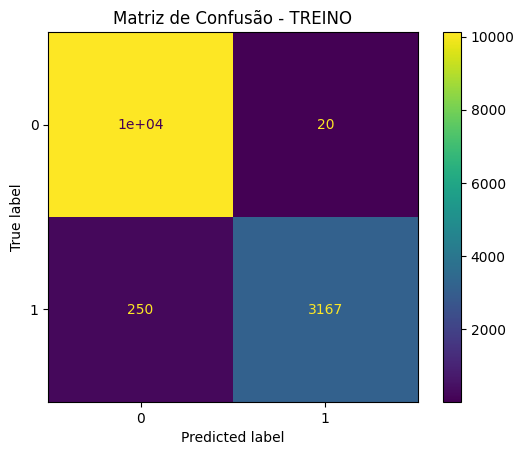

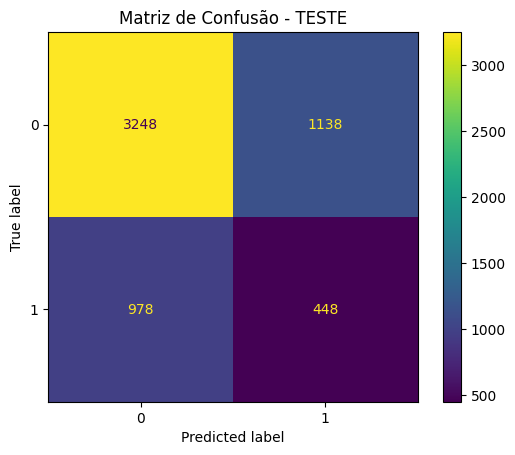

Matriz de Confusão - TREINO (lista): [[10123, 20], [250, 3167]]
Matriz de Confusão - TESTE (lista): [[3248, 1138], [978, 448]]

CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10143
           1       0.99      0.93      0.96      3417

    accuracy                           0.98     13560
   macro avg       0.98      0.96      0.97     13560
weighted avg       0.98      0.98      0.98     13560

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      4386
           1       0.28      0.31      0.30      1426

    accuracy                           0.64      5812
   macro avg       0.53      0.53      0.53      5812
weighted avg       0.65      0.64      0.64      5812



In [19]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features

numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES","DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Display the confusion matrices as lists
print("Matriz de Confusão - TREINO (lista):", train_matrix_list)
print("Matriz de Confusão - TESTE (lista):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))

A redução do número de características teve algum efeito positivo no treino e no teste, mas a complexidade do modelo ainda parece levar a overfitting. A baixa performance da classe 1 no teste sugere que mais ajustes são necessários para melhorar a generalização do modelo.

Devido ao forte desbalanceamento nos dados, onde os exemplos de não doadores são aproximadamente três vezes superiores aos de doadores, foi realizado um ajuste de pesos das classes para 'balanced'.

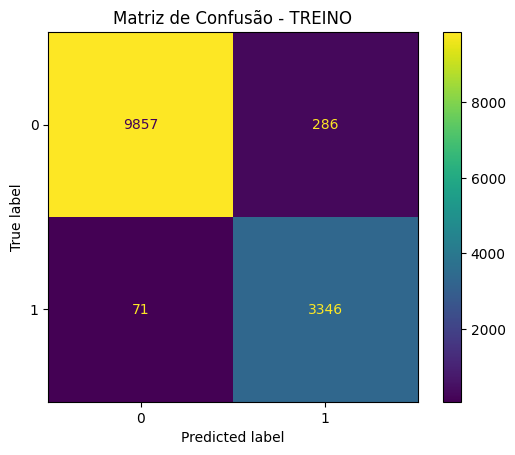

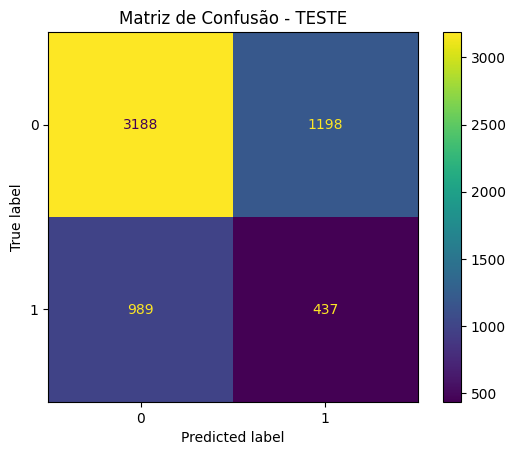

Matriz de Confusão - TREINO (lista): [[9857, 286], [71, 3346]]
Matriz de Confusão - TESTE (lista): [[3188, 1198], [989, 437]]

CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10143
           1       0.92      0.98      0.95      3417

    accuracy                           0.97     13560
   macro avg       0.96      0.98      0.97     13560
weighted avg       0.97      0.97      0.97     13560

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      4386
           1       0.27      0.31      0.29      1426

    accuracy                           0.62      5812
   macro avg       0.52      0.52      0.52      5812
weighted avg       0.64      0.62      0.63      5812



In [20]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES","DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model with class weights
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Display the confusion matrices as lists
print("Matriz de Confusão - TREINO (lista):", train_matrix_list)
print("Matriz de Confusão - TESTE (lista):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))

O ajuste de pesos para classes desbalanceadas mostrou-se vantajoso na fase de treino, mas ainda não foi suficiente para garantir uma performance adequada em dados não vistos.

No passo seguinte, foi realizada a configuração dos hiperparâmetros do modelo por meio da técnica GridSearchCV. Esta abordagem visa otimizar a performance do modelo de Árvore de Decisão ao testar múltiplas combinações de hiperparâmetros.

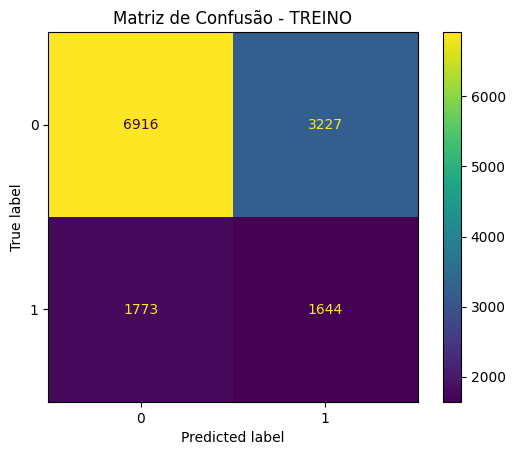

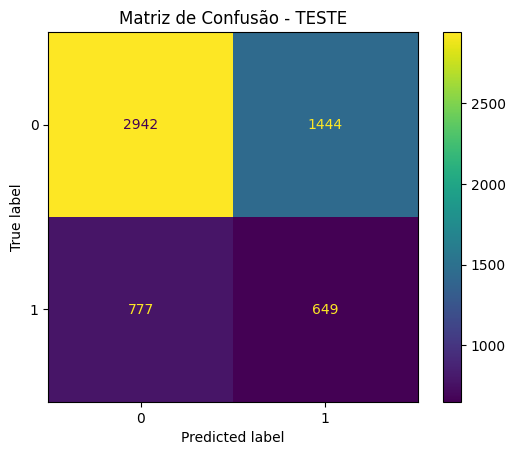

Matriz de Confusão - TREINO (lista): [[6916, 3227], [1773, 1644]]
Matriz de Confusão - TESTE (lista): [[2942, 1444], [777, 649]]

CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73     10143
           1       0.34      0.48      0.40      3417

    accuracy                           0.63     13560
   macro avg       0.57      0.58      0.57     13560
weighted avg       0.68      0.63      0.65     13560

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.79      0.67      0.73      4386
           1       0.31      0.46      0.37      1426

    accuracy                           0.62      5812
   macro avg       0.55      0.56      0.55      5812
weighted avg       0.67      0.62      0.64      5812

Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [21]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV


import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Predictions using the best model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Display the confusion matrices as lists
print("Matriz de Confusão - TREINO (lista):", train_matrix_list)
print("Matriz de Confusão - TESTE (lista):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))

# Best parameters from GridSearch
print("Melhores parâmetros encontrados:", grid_search.best_params_)

Os resultados mostram uma melhoria dos valores de recal e f1-score para a classe 1 nos dados de teste. No entanto, apesar da aplicação do GridSearchCV ter permitido uma otimização dos hiperparâmetros, os resultados ainda indicam a presença de desafios significativos. O modelo apresenta uma boa precisão para a classe 0 (não doadores), mas continua com desempenho insatisfatório para a classe 1 (doadores), refletido em baixas métricas de recall e F1-score.

Posteriormente, foram aplicadas técnicas de oversampling, como SMOTE e ADASYN. Estas técnicas de oversampling foram aplicadas para lidar com o desbalanceamento das classes no conjunto de dados, onde os exemplos de não doadores são significativamente mais numerosos do que os de doadores. O SMOTE (Synthetic Minority Over-sampling Technique) e o ADASYN (Adaptive Synthetic Sampling) criam amostras sintéticas da classe minoritária (doadores) para aumentar sua representação, visando equilibrar as classes e aumentar a variabilidade. No entanto, apesar dessas intervenções, os resultados foram insatisfatórios.


CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10143
           1       0.99      0.97      0.98     10143

    accuracy                           0.98     20286
   macro avg       0.98      0.98      0.98     20286
weighted avg       0.98      0.98      0.98     20286

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      4386
           1       0.28      0.30      0.29      1426

    accuracy                           0.63      5812
   macro avg       0.52      0.52      0.52      5812
weighted avg       0.65      0.63      0.64      5812

F1 Score (Train): 0.9806
F1 Score (Test): 0.2889


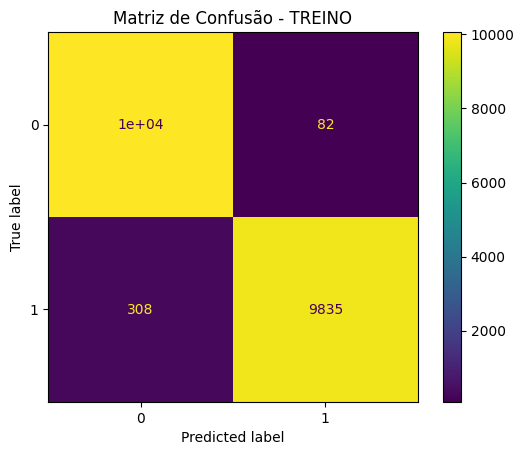

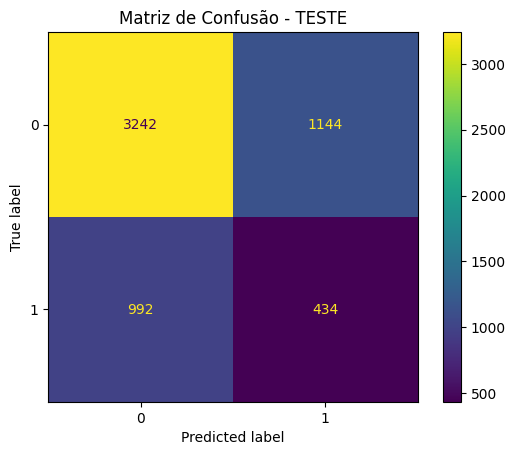

Matriz de Confusão - TREINO (lista): [[10061, 82], [308, 9835]]
Matriz de Confusão - TESTE (lista): [[3242, 1144], [992, 434]]
Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [22]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV
# Balancing with SMOTE

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE  # Import SMOTE

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Predictions using the best model
y_train_pred = best_model.predict(X_train_resampled)
y_test_pred = best_model.predict(X_test)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train_resampled, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train_resampled, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))

# Display F1 Scores
print(f"F1 Score (Train): {f1_train:.4f}")
print(f"F1 Score (Test): {f1_test:.4f}")

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train_resampled, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Display the confusion matrices as lists
print("Matriz de Confusão - TREINO (lista):", train_matrix_list)
print("Matriz de Confusão - TESTE (lista):", test_matrix_list)

# Best parameters from GridSearch
print("Melhores parâmetros encontrados:", grid_search.best_params_)

F1 Score (Train): 0.9809
F1 Score (Test): 0.2736


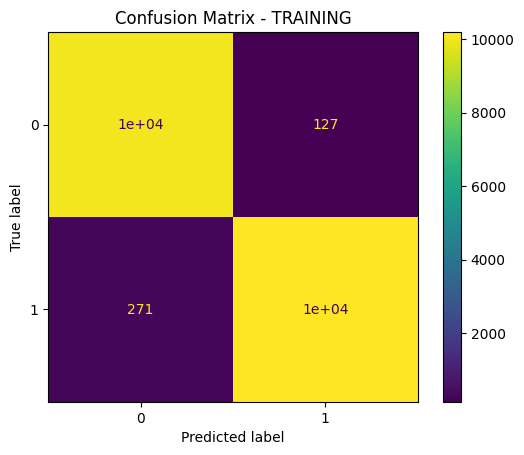

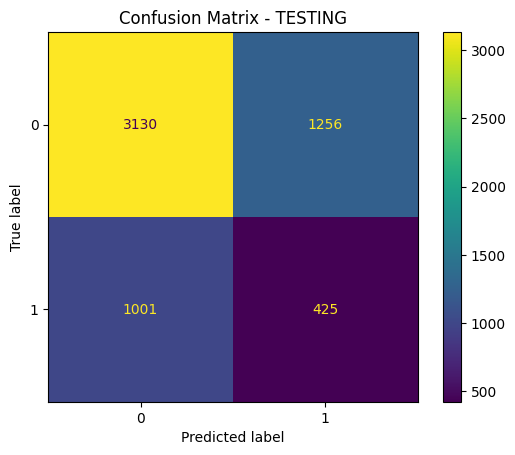

Confusion Matrix - TRAINING (list): [[10016, 127], [271, 10197]]
Confusion Matrix - TESTING (list): [[3130, 1256], [1001, 425]]
Best parameters found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [23]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV
# Balancing with ADASYN


import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import ADASYN  # Import ADASYN

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Apply ADASYN to the training data
adasyn = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Predictions using the best model
y_train_pred = best_model.predict(X_train_resampled)
y_test_pred = best_model.predict(X_test)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train_resampled, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

# Display F1 Scores
print(f"F1 Score (Train): {f1_train:.4f}")
print(f"F1 Score (Test): {f1_test:.4f}")

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train_resampled, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TESTING")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TESTING (list):", test_matrix_list)

# Best parameters from GridSearch
print("Best parameters found:", grid_search.best_params_)

Na tentativa de melhorar os resultados, foi aplicada a validação cruzada estratificada com K folds. A aplicação desta técnica visa melhorar a generalização do modelo e a precisão nas previsões, especialmente em situações onde a classe minoritária é pouco representada. Nesta técnica, o conjunto de dados é dividido em K grupos (ou "folds"), garantindo que a proporção entre as classes (neste caso, doadores e não doadores) seja mantida em cada fold. As vantagens são várias: representatividade pois mantém a distribuição original das classes em cada subdivisão do conjunto de dados, o que é especialmente importante em casos de desbalanceamento, avaliação mais estável do modelo e melhor utilização dos dados pois ao treinar e testar o modelo em diferentes subconjuntos dos dados, maximiza-se a quantidade de dados usados para o treino e a validação, o que origina uma análise mais completa.

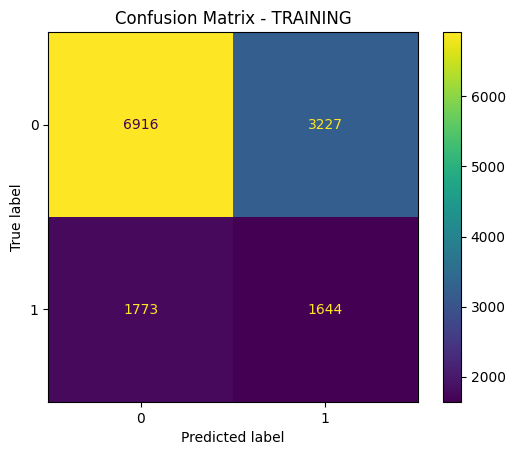

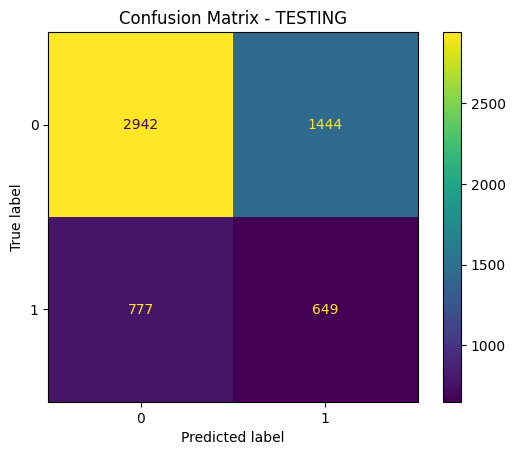

Confusion Matrix - TRAINING (list): [[6916, 3227], [1773, 1644]]
Confusion Matrix - TESTING (list): [[2942, 1444], [777, 649]]

CLASSIFICATION - TRAINING:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73     10143
           1       0.34      0.48      0.40      3417

    accuracy                           0.63     13560
   macro avg       0.57      0.58      0.57     13560
weighted avg       0.68      0.63      0.65     13560

CLASSIFICATION - TESTING:
              precision    recall  f1-score   support

           0       0.79      0.67      0.73      4386
           1       0.31      0.46      0.37      1426

    accuracy                           0.62      5812
   macro avg       0.55      0.56      0.55      5812
weighted avg       0.67      0.62      0.64      5812

Best parameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [24]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV
# Applying Stratified K-Fold Cross-Validation


import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV with Stratified K-Fold
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf, scoring='f1', n_jobs=-1)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Predictions using the best model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TESTING")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TESTING (list):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICATION - TRAINING:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION - TESTING:")
print(classification_report(y_test, y_test_pred))

# Best parameters from GridSearch
print("Best parameters found:", grid_search.best_params_)

Não houve alteração dos resultados.

Por fim executou-se o ajuste do threshold de classificação. Este é uma técnica poderosa para otimizar modelos preditivos, permitindo um ajuste fino das saídas do modelo para atender às exigências específicas de diferentes aplicações. No presente caso, o threshold de classificação foi ajustado com base na curva Precision-Recall para equilibrar melhor a precisão e a sensibilidade (recall), com enfoque na classe de doadores. Neste contexto, identificar mais casos positivos mesmo que isso aumente a taxa de falsos positivos é crucial para o desempenho do modelo.

Optimal threshold: 0.41


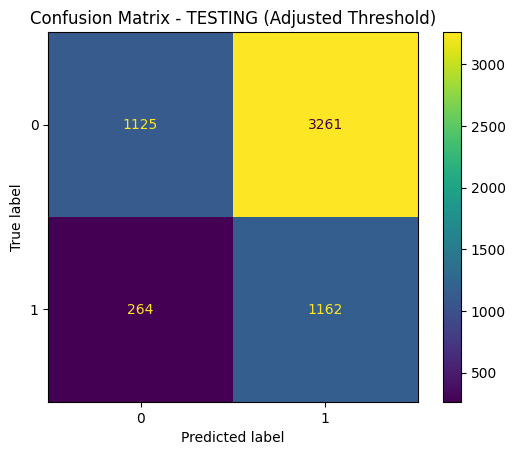

Confusion Matrix - TESTING (Adjusted Threshold) (list): [[1125, 3261], [264, 1162]]

Evaluation Metrics - Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.81      0.26      0.39      4386
           1       0.26      0.81      0.40      1426

    accuracy                           0.39      5812
   macro avg       0.54      0.54      0.39      5812
weighted avg       0.68      0.39      0.39      5812

F1 Score (Adjusted Threshold): 0.3973


In [25]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV
# Applying Stratified K-Fold Cross-Validation
# Adjusting classification threshold based on Precision-Recall curve


import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV with Stratified K-Fold
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf, scoring='f1', n_jobs=-1)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Get predicted probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate F1 scores for each threshold
f1_scores = []
for p, r in zip(precision, recall):
    if (p + r) == 0:
        f1_scores.append(0.0)  # F1 score is zero if both precision and recall are zero
    else:
        f1_scores.append(2 * (p * r) / (p + r))

# Convert to a NumPy array for easier indexing
f1_scores = np.array(f1_scores)

# Determine the threshold with the best F1 score
best_index = np.argmax(f1_scores)
optimal_threshold = thresholds[best_index] if best_index < len(thresholds) else None

print(f"Optimal threshold: {optimal_threshold:.2f}")

# Make binary predictions based on the optimal threshold
y_test_pred_adjusted = (y_probs >= optimal_threshold).astype(int)

# Evaluation with the adjusted threshold
cm_test_adjusted = confusion_matrix(y_test, y_test_pred_adjusted)
test_matrix_adjusted_list = cm_test_adjusted.tolist()

disp_test_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_test_adjusted, display_labels=best_model.classes_)
disp_test_adjusted.plot()
plt.title("Confusion Matrix - TESTING (Adjusted Threshold)")
plt.show()

# Display the confusion matrix as a list
print("Confusion Matrix - TESTING (Adjusted Threshold) (list):", test_matrix_adjusted_list)

# Evaluation metrics for the adjusted threshold predictions
print("\nEvaluation Metrics - Adjusted Threshold:")
print(classification_report(y_test, y_test_pred_adjusted))

# F1 Score for class 1 (donors) with the adjusted threshold
f1_score_adjusted = f1_score(y_test, y_test_pred_adjusted, pos_label=1)
print(f"F1 Score (Adjusted Threshold): {f1_score_adjusted:.4f}")



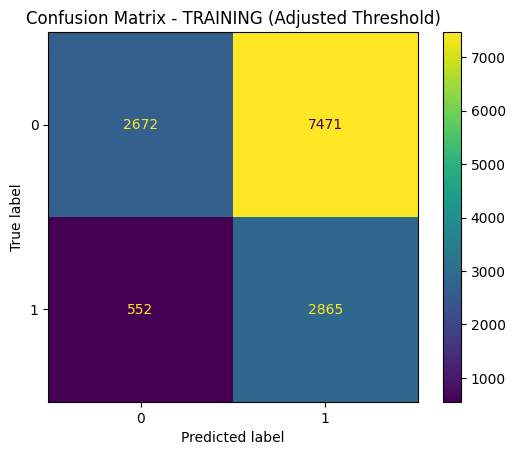

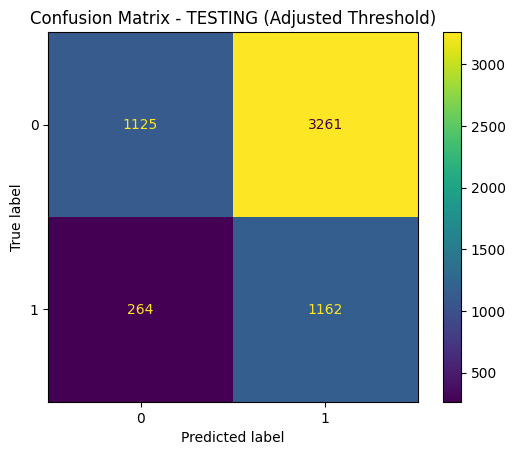

Confusion Matrix - TRAINING (Adjusted Threshold) (list): [[2672, 7471], [552, 2865]]
Confusion Matrix - TESTING (Adjusted Threshold) (list): [[1125, 3261], [264, 1162]]

Evaluation Metrics - TRAINING (Adjusted Threshold):
              precision    recall  f1-score   support

           0       0.83      0.26      0.40     10143
           1       0.28      0.84      0.42      3417

    accuracy                           0.41     13560
   macro avg       0.55      0.55      0.41     13560
weighted avg       0.69      0.41      0.40     13560

F1 Score (Adjusted Threshold - TRAINING): 0.4166

Evaluation Metrics - TESTING (Adjusted Threshold):
              precision    recall  f1-score   support

           0       0.81      0.26      0.39      4386
           1       0.26      0.81      0.40      1426

    accuracy                           0.39      5812
   macro avg       0.54      0.54      0.39      5812
weighted avg       0.68      0.39      0.39      5812

F1 Score (Adjusted Thre

In [26]:
# After calculating the optimal threshold and making predictions

# Make binary predictions for the training set using the optimal threshold
y_train_probs = best_model.predict_proba(X_train)[:, 1]
y_train_pred_adjusted = (y_train_probs >= optimal_threshold).astype(int)

# Confusion Matrix - Train with adjusted threshold
cm_train_adjusted = confusion_matrix(y_train, y_train_pred_adjusted)
train_matrix_adjusted_list = cm_train_adjusted.tolist()

disp_train_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_train_adjusted, display_labels=best_model.classes_)
disp_train_adjusted.plot()
plt.title("Confusion Matrix - TRAINING (Adjusted Threshold)")
plt.show()

# Confusion Matrix - Test with adjusted threshold
cm_test_adjusted = confusion_matrix(y_test, y_test_pred_adjusted)
test_matrix_adjusted_list = cm_test_adjusted.tolist()

disp_test_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_test_adjusted, display_labels=best_model.classes_)
disp_test_adjusted.plot()
plt.title("Confusion Matrix - TESTING (Adjusted Threshold)")
plt.show()

# Display confusion matrices as lists
print("Confusion Matrix - TRAINING (Adjusted Threshold) (list):", train_matrix_adjusted_list)
print("Confusion Matrix - TESTING (Adjusted Threshold) (list):", test_matrix_adjusted_list)

# Evaluation metrics for the adjusted threshold predictions for training set
print("\nEvaluation Metrics - TRAINING (Adjusted Threshold):")
print(classification_report(y_train, y_train_pred_adjusted))

# F1 Score for class 1 (donors) with the adjusted threshold
f1_score_train_adjusted = f1_score(y_train, y_train_pred_adjusted, pos_label=1)
print(f"F1 Score (Adjusted Threshold - TRAINING): {f1_score_train_adjusted:.4f}")

# Continue with previously shown test metrics evaluation
print("\nEvaluation Metrics - TESTING (Adjusted Threshold):")
print(classification_report(y_test, y_test_pred_adjusted))

# F1 Score for class 1 (donors) with the adjusted threshold
f1_score_test_adjusted = f1_score(y_test, y_test_pred_adjusted, pos_label=1)
print(f"F1 Score (Adjusted Threshold - TESTING): {f1_score_test_adjusted:.4f}")

Os resultados mostram que as métricas de desempenho para as classes 0 e 1 são desiguais após o ajuste do threshold:

    No conjunto de teste, a precision e o recall para a classe 1 (doadores) estão relativamente baixos (0.26 e 0.81, respectivamente), indicando que, embora o modelo identifique bastante bem os doadores (alto recall), comete muitos erros ao classificar pessoas como doadores quando não são (baixa precisão).
    A classe 0 (não doadores) apresenta uma relação oposta, com uma melhor precision (0.81) mas um recall baixo (0.26), sugerindo que muitos não doadores estão a ser erroneamente identificados.

O ajuste do threshold levou a uma melhoria na identificação da classe 1, embora com custos na precisão, refletindo um compromisso observado frequentemente em problemas de classificação com classes desbalanceadas. Tal facto, resulta num cenário onde o modelo alcança um equilíbrio nos exemplos corretamente identificados entre as classes:

    Classe 1 (doadores) tem um recall alto, indicando que muitos doadores foram identificados corretamente, mas a precisão baixa sugere a presença de muitos falsos positivos.
    Classe 0 (não doadores) tem um desempenho melhor em precisão, mas não consegue identificar muitos dos não doadores corretamente.

O resultado é que o modelo termina com uma "igualdade" nas quantidades de exemplos corretamente identificados na classe 0 e classe 1 dentro do contexto do threshold ajustado, mas isso resulta num modelo que ainda falha em generalizar bem, especialmente em relação a falsos positivos e falsos negativos.

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...